# 프로젝트 : 챗봇 만들기

## Step 0. Mecab 설치

In [1]:
%%capture
# Colab에서 mecab 설치 (최초 1회만 실행)
!pip install -qq konlpy
!pip install -qq mecab-python3
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install nltk
!pip install gensim
import numpy
import pandas
import torch
import nltk
import gensim

print(numpy.__version__)
print(pandas.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.2 MB/s eta 0:00:00
2.0.2
2.2.2
2.11.0+cu128
3.9.1
4.4.0


In [4]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU만 사용")

True
Tesla T4


## Step 1. 데이터 다운로드

In [7]:
import pandas as pd

# 심볼릭 링크로 ChatbotData.csv가 준비되어 있다고 가정
data = pd.read_csv('./ChatbotData.csv')

questions = data['Q'].tolist()
answers = data['A'].tolist()

print(f"질문 개수: {len(questions)}, 답변 개수: {len(answers)}")
print(questions[:3])
print(answers[:3])

질문 개수: 11823, 답변 개수: 11823
['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다']
['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.']


## Step 2. 데이터 정제

In [8]:
import re

def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()
    # 한글, 영문, 숫자, 주요 특수문자(. , ! ?)를 제외한 나머지 제거
    sentence = re.sub(r"[^0-9a-zA-Zㄱ-ㅎㅏ-ㅣ가-힣.,!?]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

# 테스트
print(preprocess_sentence("아 진짜?? ㅋㅋㅋ 12시 땡!!!"))

아 진짜?? ㅋㅋㅋ 12시 땡!!!


## Step 3. 데이터 토큰화

In [22]:
from konlpy.tag import Mecab

mecab = Mecab()

def build_corpus(src_data, tgt_data, tokenize_fn, max_len=25):
    src_corpus, tgt_corpus = [], []
    src_seen, tgt_seen = set(), set()

    for src_sent, tgt_sent in zip(src_data, tgt_data):
        src_clean = preprocess_sentence(src_sent)
        tgt_clean = preprocess_sentence(tgt_sent)

        src_tokens = tokenize_fn(src_clean)
        tgt_tokens = tokenize_fn(tgt_clean)

        if len(src_tokens) == 0 or len(tgt_tokens) == 0:
            continue
        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            continue

        src_key = " ".join(src_tokens)
        tgt_key = " ".join(tgt_tokens)

        # 소스는 소스대로, 타겟은 타겟대로 중복 검사 (쌍은 함께 유지)
        if src_key in src_seen or tgt_key in tgt_seen:
            continue

        src_seen.add(src_key)
        tgt_seen.add(tgt_key)
        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    return src_corpus, tgt_corpus

que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs, max_len=40)

print(len(que_corpus), len(ans_corpus))
print(que_corpus[:2])
print(ans_corpus[:2])

7683 7683
[['12', '시', '땡', '!'], ['1', '지망', '학교', '떨어졌', '어']]
[['하루', '가', '또', '가', '네요', '.'], ['위로', '해', '드립니다', '.']]


## Step 4. 데이터 증강(Lexical Substitution)

In [10]:
# Facebook fastText의 한국어 사전학습 벡터
import urllib.request

url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ko.300.vec.gz"
urllib.request.urlretrieve(url, "cc.ko.300.vec.gz")

('cc.ko.300.vec.gz', <http.client.HTTPMessage at 0x7a9298507440>)

In [11]:
import gensim
from gensim.models import KeyedVectors

# .gz 상태로도 gensim이 바로 읽을 수 있습니다 (압축 해제 불필요)
vectors = KeyedVectors.load_word2vec_format("cc.ko.300.vec.gz", binary=False, limit=50000)
# limit: 상위 20만 단어만 로드 (전체 로드시 메모리 많이 사용, 시간도 오래 걸림)

In [23]:
import random

similar_cache = {}

def get_similar(word, vectors, topn=5):
    if word in similar_cache:
        return similar_cache[word]
    try:
        result = [w for w, _ in vectors.most_similar(word, topn=topn)]
    except KeyError:
        result = []
    similar_cache[word] = result
    return result

def lexical_sub(tokens, vectors, topn=5, prob=0.3):
    new_tokens = tokens.copy()
    for i, token in enumerate(tokens):
        if random.random() < prob:
            candidates = get_similar(token, vectors, topn)
            if candidates:
                new_tokens[i] = random.choice(candidates)
    return new_tokens

def augment_corpus(corpus, vectors):
    return [lexical_sub(tokens, vectors) for tokens in corpus]

que_aug1 = augment_corpus(que_corpus, vectors)
ans_aug1 = ans_corpus
que_aug2 = que_corpus
ans_aug2 = augment_corpus(ans_corpus, vectors)

que_corpus = que_corpus + que_aug1 + que_aug2
ans_corpus = ans_corpus + ans_aug1 + ans_aug2

print(f"전체 데이터 개수: {len(que_corpus)}")


전체 데이터 개수: 23049


In [24]:
# 중복 제거 효과만 따로 확인
unique_questions = set(preprocess_sentence(q) for q in questions)
unique_answers = set(preprocess_sentence(a) for a in answers)
print(f"원본 질문: {len(questions)}, 중복 제거 후 고유 질문: {len(unique_questions)}")
print(f"원본 답변: {len(answers)}, 중복 제거 후 고유 답변: {len(unique_answers)}")

원본 질문: 11823, 중복 제거 후 고유 질문: 11661
원본 답변: 11823, 중복 제거 후 고유 답변: 7779


## Step 5. 데이터 벡터화

In [25]:
import numpy as np
import torch
from collections import Counter

# <start>, <end> 토큰 추가
ans_corpus = [["<start>"] + tokens + ["<end>"] for tokens in ans_corpus]

# 소스+타겟 통합 단어 사전 구축 (같은 언어이므로 임베딩 공유 목적)
def build_vocab(corpus_list, min_freq=1):
    counter = Counter()
    for corpus in corpus_list:
        for tokens in corpus:
            counter.update(tokens)
    vocab = ['<pad>', '<unk>', '<start>', '<end>']
    vocab += [w for w, f in counter.items() if f >= min_freq and w not in vocab]
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}
    return word2idx, idx2word

word2idx, idx2word = build_vocab([que_corpus, ans_corpus])
vocab_size = len(word2idx)
PAD_IDX = word2idx['<pad>']

def vectorize(corpus, word2idx):
    return [[word2idx.get(t, word2idx['<unk>']) for t in tokens] for tokens in corpus]

enc_ids = vectorize(que_corpus, word2idx)
dec_ids = vectorize(ans_corpus, word2idx)

max_len_enc = max(len(s) for s in enc_ids)
max_len_dec = max(len(s) for s in dec_ids)

def pad_sequences(sequences, max_len, pad_value):
    arr = np.full((len(sequences), max_len), pad_value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        length = min(len(seq), max_len)
        arr[i, :length] = seq[:length]
    return arr

enc_train = pad_sequences(enc_ids, max_len_enc, PAD_IDX)
dec_train = pad_sequences(dec_ids, max_len_dec, PAD_IDX)

print(f"Vocab size: {vocab_size}")
print(f"enc_train: {enc_train.shape}, dec_train: {dec_train.shape}")

Vocab size: 8944
enc_train: (23049, 32), dec_train: (23049, 42)


## Step 6. 훈련하기 (Transformer)

In [26]:
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        b = q.size(0)
        Q = self.w_q(q).view(b, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(b, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(b, -1, self.n_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn, V).transpose(1, 2).contiguous().view(b, -1, self.n_heads * self.d_k)
        return self.w_o(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model))

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = self.norm1(x + self.drop(self.attn(x, x, x, mask)))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask, tgt_mask):
        x = self.norm1(x + self.drop(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.drop(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.drop(self.ffn(x)))
        return x


class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout, max_len, pad_idx):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)  # 공유 임베딩
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.drop = nn.Dropout(dropout)
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def make_src_mask(self, src):
        return (src != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        pad_mask = (tgt != self.pad_idx).unsqueeze(1).unsqueeze(2)
        L = tgt.size(1)
        sub_mask = torch.tril(torch.ones((L, L), device=tgt.device)).bool()
        return pad_mask & sub_mask

    def encode(self, src, src_mask):
        x = self.drop(self.pos_enc(self.embedding(src) * math.sqrt(self.d_model)))
        for layer in self.enc_layers:
            x = layer(x, src_mask)
        return x

    def decode(self, tgt, enc_out, src_mask, tgt_mask):
        x = self.drop(self.pos_enc(self.embedding(tgt) * math.sqrt(self.d_model)))
        for layer in self.dec_layers:
            x = layer(x, enc_out, src_mask, tgt_mask)
        return self.fc_out(x)

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        enc_out = self.encode(src, src_mask)
        return self.decode(tgt, enc_out, src_mask, tgt_mask)

### 훈련 루프 (과적합 방지용 소규모 하이퍼파라미터):

In [27]:
from torch.utils.data import Dataset, DataLoader

class ChatbotDataset(Dataset):
    def __init__(self, enc, dec):
        self.enc, self.dec = enc, dec
    def __len__(self):
        return len(self.enc)
    def __getitem__(self, idx):
        return torch.tensor(self.enc[idx]), torch.tensor(self.dec[idx])

dataset = ChatbotDataset(enc_train, dec_train)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

D_MODEL = 256
model = Transformer(
    vocab_size=vocab_size, d_model=D_MODEL, n_heads=8, n_layers=1,
    d_ff=1024, dropout=0.3, max_len=max(max_len_enc, max_len_dec) + 10, pad_idx=PAD_IDX
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

WARMUP_STEPS = 1000
def get_lr(step, d_model, warmup):
    step = max(step, 1)
    return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)

step_count = 0
N_EPOCHS = 10

model.train()
for epoch in range(N_EPOCHS):
    total_loss = 0
    for enc_batch, dec_batch in dataloader:
        step_count += 1
        lr = get_lr(step_count, D_MODEL, WARMUP_STEPS)
        for g in optimizer.param_groups:
            g['lr'] = lr

        enc_batch, dec_batch = enc_batch.to(device), dec_batch.to(device)
        dec_input, dec_target = dec_batch[:, :-1], dec_batch[:, 1:]

        optimizer.zero_grad()
        output = model(enc_batch, dec_input)
        loss = criterion(output.reshape(-1, vocab_size), dec_target.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{N_EPOCHS}, Loss: {total_loss/len(dataloader):.4f}")

Epoch 1/10, Loss: 5.6415
Epoch 2/10, Loss: 4.0398
Epoch 3/10, Loss: 3.6831
Epoch 4/10, Loss: 3.4691
Epoch 5/10, Loss: 3.3018
Epoch 6/10, Loss: 3.1664
Epoch 7/10, Loss: 3.0565
Epoch 8/10, Loss: 2.9577
Epoch 9/10, Loss: 2.8682
Epoch 10/10, Loss: 2.7869


### 예문에 대한 답변 생성:

In [28]:
def translate(sentence, model, word2idx, idx2word, tokenizer, max_len = 25, repetition_penalty=1.5):
    model.eval()
    tokens = tokenizer(preprocess_sentence(sentence))
    ids = [word2idx.get(t, word2idx['<unk>']) for t in tokens]
    src = torch.tensor([ids], device=device)
    src_mask = model.make_src_mask(src)

    with torch.no_grad():
        enc_out = model.encode(src, src_mask)

    dec_input = torch.tensor([[word2idx['<start>']]], device=device)
    generated_ids = []

    for _ in range(max_len):
        tgt_mask = model.make_tgt_mask(dec_input)
        with torch.no_grad():
            out = model.decode(dec_input, enc_out, src_mask, tgt_mask)

        logits = out[:, -1, :].clone()

        # 이미 나온 단어들의 확률을 낮춰서 반복을 억제
        for prev_id in set(generated_ids):
            logits[0, prev_id] /= repetition_penalty

        next_id = logits.argmax(dim=-1).item()
        generated_ids.append(next_id)
        dec_input = torch.cat([dec_input, torch.tensor([[next_id]], device=device)], dim=1)

        if next_id == word2idx['<end>']:
            break

    return " ".join(idx2word[i] for i in generated_ids[:-1] if idx2word[i] != '<end>')

examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

for ex in examples:
    print(f"입력: {ex}")
    print(f"출력: {translate(ex, model, word2idx, idx2word, mecab.morphs)}\n")

입력: 지루하다, 놀러가고 싶어.
출력: 저 도 데려가 세요 .

입력: 오늘 일찍 일어났더니 피곤하다.
출력: 언젠간 괜찮 아요 .

입력: 간만에 여자친구랑 데이트 하기로 했어.
출력: 또 데이트 할 수 있 겠 네요 .

입력: 집에 있는다는 소리야.
출력: 짝사랑 앞 에 는 게 좋 겠 어요 .



## Step 7. 성능 측정 (BLEU Score)

In [29]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import random

def calculate_bleu(model, que_corpus, ans_corpus, word2idx, idx2word, tokenizer, n_samples=100):
    smoothie = SmoothingFunction().method4
    scores = []
    idxs = random.sample(range(len(que_corpus)), min(n_samples, len(que_corpus)))

    for i in idxs:
        src_sentence = " ".join(que_corpus[i])
        reference = ans_corpus[i][1:-1]  # <start>, <end> 제외
        hypothesis = translate(src_sentence, model, word2idx, idx2word, tokenizer).split()
        if hypothesis and hypothesis[-1] == '<end>':
            hypothesis = hypothesis[:-1]
        scores.append(sentence_bleu([reference], hypothesis, smoothing_function=smoothie))

    return sum(scores) / len(scores)

bleu_score = calculate_bleu(model, que_corpus, ans_corpus, word2idx, idx2word, mecab.morphs)
print(f"평균 BLEU Score: {bleu_score:.4f}")

평균 BLEU Score: 0.0702


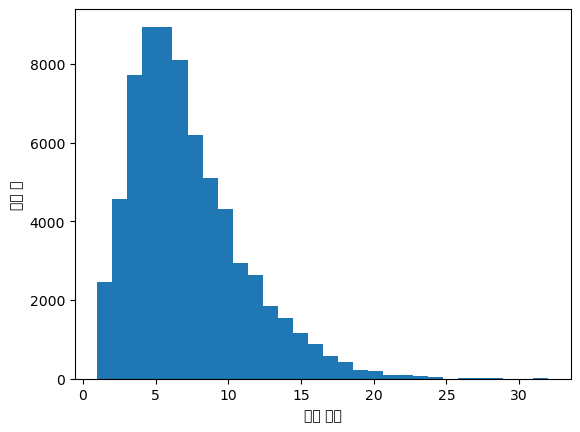

평균: 7.5
최대: 32
90th percentile: 13


In [ ]:
import matplotlib.pyplot as plt

lengths = [len(t) for t in que_corpus]  # 각 문장의 토큰 개수 리스트
plt.hist(lengths, bins=30)
plt.xlabel("토큰 개수")
plt.ylabel("문장 수")
plt.show()

print(f"평균: {sum(lengths)/len(lengths):.1f}")
print(f"최대: {max(lengths)}")
print(f"90th percentile: {sorted(lengths)[int(len(lengths)*0.9)]}")

max_len=25로 설정, dropout = 0.3, d_model 256으로 수정 후 다시 훈

![](1.png)

![](7.png)

# 회고

원본 11,823개 쌍에 전처리를 적용한 결과, 질문은 11,661개(약 1.4% 감소)로 큰 변화가 없었으나 답변은 7,779개(약 34% 감소)로 크게 줄었다. 이는 챗봇 데이터 특성상 "저도요", "감사합니다" 등 범용 답변이 여러 질문에 반복적으로 사용되기 때문으로 분석된다. max_len=25 필터링으로는 5개 문장만 추가로 제외되어 영향은 미미했다. 최종적으로 질문/답변 쌍 기준 7,654개의 고유 데이터를 확보했으며, Lexical Substitution 기반 augmentation(3배)을 적용해 22,962개의 훈련 데이터셋을 구축하였다.

